# UZCARD card payments — where the money leaks

60,320 transactions · 2,000 customers · 3,286 cards · 600 merchants · full-year 2023

This notebook works through two questions:

1. **6.1% of transactions are declined. Whose are they?** The obvious answer — students —
   turns out to be a Simpson's paradox. The real cause is one card product.
2. **Disputes are rare but expensive. Would the bank's own risk labels have caught them?**
   One of its two labels works. The other is inverted.

Every number here comes from the queries in [`../sql/`](../sql); this notebook adds the
significance tests and the charts.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from matplotlib.ticker import FuncFormatter
from scipy import stats

# psycopg2 handles the read-only SELECTs in this notebook perfectly well; pandas warns
# only because it cannot introspect a non-SQLAlchemy connection. Not worth a dependency.
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

ROOT = Path.cwd().parent.parent          # repo root, from notebooks/
ASSETS = Path.cwd().parent / "assets"
ASSETS.mkdir(exist_ok=True)

env = {}
for line in (ROOT / ".env").read_text(encoding="utf-8").splitlines():
    line = line.strip()
    if line and not line.startswith("#") and "=" in line:
        key, _, value = line.partition("=")
        env[key.strip()] = value.strip()

con = psycopg2.connect(host=env["PGHOST"], port=env["PGPORT"], dbname=env["PGDATABASE"],
                       user=env["PGUSER"], password=env["PGPASSWORD"])


def q(sql):
    return pd.read_sql_query(sql, con)


print(q("SELECT count(*) AS transactions FROM uzcard.transactions").to_string(index=False))

 transactions
        60320


### Chart style

One palette for the whole project, applied through `rcParams` so no chart re-specifies it.
The categorical hues are used in fixed slot order and never cycled — the ordering is what
keeps adjacent series distinguishable under colour-vision deficiency.

In [2]:
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
BASELINE  = "#c3c2b7"

# categorical slots, fixed order
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]

CRITICAL = "#d03b3b"     # status colour, reserved for the outlier - never a series
NEUTRAL  = "#c9c8c2"     # the "nothing to see here" bars

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 130, "savefig.dpi": 150, "savefig.bbox": "tight",
})

PCT = FuncFormatter(lambda v, _: f"{v:g}%")


def finish(ax, subtitle=None, xgrid=False):
    """Recessive grid on the value axis only, and a subtitle in secondary ink."""
    ax.grid(axis="x" if xgrid else "y", alpha=1.0)
    ax.set_axisbelow(True)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(BASELINE)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9.5,
                color=INK_2, va="bottom")


def save(fig, name):
    fig.savefig(ASSETS / f"{name}.png")
    print(f"saved assets/{name}.png")

---

## 1. Baseline — what normal looks like

Two of these numbers matter later: the **6.1% decline rate**, which the rest of section 2
decomposes, and the **0.33% dispute rate**, which section 3 shows is almost entirely
produced by five merchants.

In [3]:
baseline = q("""
    SELECT txn_status,
           count(*) AS txns,
           round(100.0 * count(*) / sum(count(*)) OVER (), 2) AS pct,
           sum(amount_uzs) AS total_uzs
    FROM uzcard.transactions
    GROUP BY txn_status ORDER BY txns DESC
""")
baseline["total_uzs"] = baseline["total_uzs"].map(lambda v: f"{v:,}")
baseline

,txn_status,txns,pct,total_uzs
0,approved,56040,92.9,"11,536,051,000.0"
1,declined,3678,6.1,"708,704,100.0"
2,reversed,602,1.0,"115,174,000.0"


In [4]:
channels = q("""
    SELECT te.channel,
           count(*) AS txns,
           round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct_of_txns,
           percentile_cont(0.5) WITHIN GROUP (ORDER BY t.amount_uzs)
               FILTER (WHERE t.txn_status = 'approved')::bigint AS median_ticket_uzs,
           round(100.0 * count(*) FILTER (WHERE t.txn_status = 'declined')
                 / count(*), 2) AS decline_pct,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 3)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.terminals te ON te.terminal_id = t.terminal_id
    GROUP BY te.channel ORDER BY txns DESC
""")
channels

,channel,txns,pct_of_txns,median_ticket_uzs,decline_pct,dispute_pct
0,POS,28692,47.6,99500,6.09,0.068
1,ECOM,14482,24.0,103200,5.75,1.244
2,QR,8005,13.3,100500,6.47,0.081
3,ATM,5482,9.1,398800,6.31,0.118
4,P2P,3659,6.1,300600,6.40,0.030


`terminals.channel` is used throughout instead of `transactions.entry_mode`. `entry_mode`
puts ATM withdrawals, P2P transfers and chip-at-POS in one `chip` bucket — three
behaviours with a 4× spread in median ticket size (398,800 UZS at an ATM against 99,500
at a POS terminal). Where the two columns overlap they agree perfectly, so preferring the
richer one costs nothing.

---

## 2. Declines: the segment number is hiding the cause
### 2.1 The obvious answer

saved assets/01-decline-by-segment.png


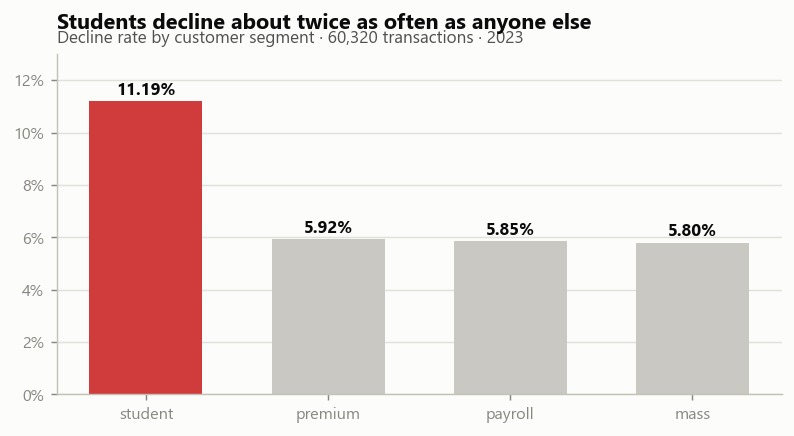

In [5]:
seg = q("""
    SELECT cu.customer_segment AS segment,
           count(*) AS txns,
           count(*) FILTER (WHERE t.txn_status = 'declined') AS declines,
           round(100.0 * count(*) FILTER (WHERE t.txn_status = 'declined')
                 / count(*), 2) AS decline_pct
    FROM uzcard.transactions t
    JOIN uzcard.cards c      ON c.card_id = t.card_id
    JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    GROUP BY 1 ORDER BY 4 DESC
""")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
colors = [CRITICAL if s == "student" else NEUTRAL for s in seg["segment"]]
bars = ax.bar(seg["segment"], seg["decline_pct"], color=colors, width=0.62)
for bar, v in zip(bars, seg["decline_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.25, f"{v:.2f}%",
            ha="center", fontsize=9.5, color=INK, fontweight="bold")
ax.set_ylim(0, 13)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("Students decline about twice as often as anyone else")
finish(ax, "Decline rate by customer segment · 60,320 transactions · 2023")
save(fig, "01-decline-by-segment")
plt.show()

Students sit 5.27 points above the next segment, while the other three are within 0.07
points of each other. Read on its own this is a clear instruction: tighten student credit.

It is the wrong instruction.

### 2.2 The same data, crossed with card product tier

saved assets/02-decline-segment-x-tier.png


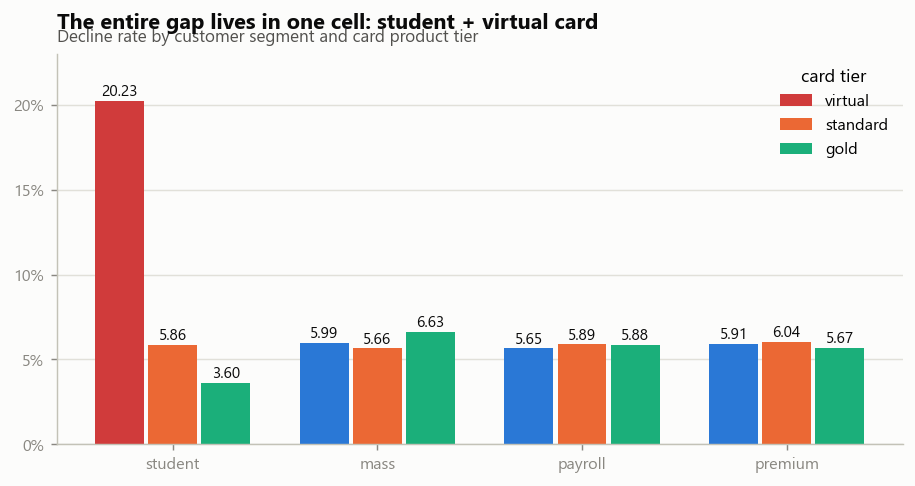

In [6]:
cross = q("""
    SELECT cu.customer_segment AS segment,
           c.product_tier AS tier,
           count(*) AS txns,
           count(DISTINCT c.card_id) AS cards,
           round(100.0 * count(*) FILTER (WHERE t.txn_status = 'declined')
                 / count(*), 2) AS decline_pct
    FROM uzcard.transactions t
    JOIN uzcard.cards c      ON c.card_id = t.card_id
    JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    GROUP BY 1, 2
""")
pivot = cross.pivot(index="segment", columns="tier", values="decline_pct")
pivot = pivot.loc[["student", "mass", "payroll", "premium"], ["virtual", "standard", "gold"]]

fig, ax = plt.subplots(figsize=(8.4, 3.9))
x = np.arange(len(pivot.index))
width = 0.26
for i, tier in enumerate(pivot.columns):
    vals = pivot[tier].values
    # the one cell that carries the whole effect gets the status colour
    cols = [CRITICAL if (tier == "virtual" and seg_name == "student") else SERIES[i]
            for seg_name in pivot.index]
    bars = ax.bar(x + (i - 1) * width, vals, width * 0.92, color=cols, label=tier)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.2f}",
                ha="center", fontsize=8.5, color=INK)
ax.set_xticks(x, pivot.index)
ax.set_ylim(0, 23)
ax.yaxis.set_major_formatter(PCT)
ax.legend(title="card tier", loc="upper right")
ax.set_title("The entire gap lives in one cell: student + virtual card")
finish(ax, "Decline rate by customer segment and card product tier")
save(fig, "02-decline-segment-x-tier")
plt.show()

Student **virtual** cards decline at 20.23%. Student **standard** cards decline at 5.86% —
the same as everybody else. Virtual cards held by non-students run 5.65–5.99%, also
unremarkable.

Neither attribute is a risk factor on its own. Only the intersection is.

### 2.3 The decisive comparison

saved assets/03-decisive-comparison.png


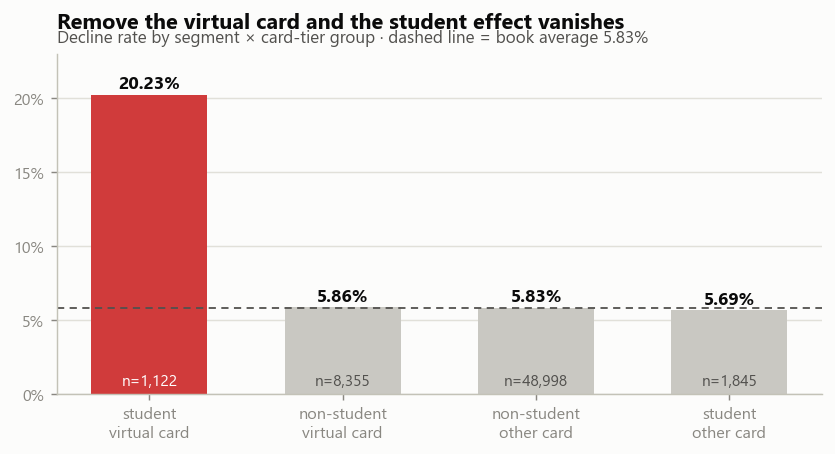

In [7]:
groups = q("""
    WITH classified AS (
        SELECT t.txn_status,
               cu.customer_segment = 'student' AS is_student,
               c.product_tier = 'virtual'      AS is_virtual
        FROM uzcard.transactions t
        JOIN uzcard.cards c      ON c.card_id = t.card_id
        JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    )
    SELECT CASE WHEN is_student AND is_virtual     THEN 'student\nvirtual card'
                WHEN is_student                    THEN 'student\nother card'
                WHEN is_virtual                    THEN 'non-student\nvirtual card'
                ELSE                                    'non-student\nother card' END AS grp,
           count(*) AS txns,
           count(*) FILTER (WHERE txn_status = 'declined') AS declines,
           round(100.0 * count(*) FILTER (WHERE txn_status = 'declined')
                 / count(*), 2) AS decline_pct
    FROM classified GROUP BY 1 ORDER BY 4 DESC
""")

fig, ax = plt.subplots(figsize=(7.6, 3.4))
cols = [CRITICAL] + [NEUTRAL] * 3
bars = ax.bar(groups["grp"], groups["decline_pct"], color=cols, width=0.6)
for bar, v, n in zip(bars, groups["decline_pct"], groups["txns"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, f"{v:.2f}%",
            ha="center", fontsize=10, color=INK, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, 0.6, f"n={n:,}",
            ha="center", fontsize=8.5, color="white" if v > 15 else INK_2)
# the baseline is named in the subtitle rather than annotated inline - at this
# scale an inline label collides with the right-hand bar's value
ax.axhline(5.83, color=INK_2, lw=1, ls=(0, (4, 3)))
ax.set_ylim(0, 23)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("Remove the virtual card and the student effect vanishes")
finish(ax, "Decline rate by segment × card-tier group · dashed line = book average 5.83%")
save(fig, "03-decisive-comparison")
plt.show()

### 2.4 Significance

In [8]:
def two_prop(x1, n1, x2, n2, label_a, label_b):
    p1, p2 = x1 / n1, x2 / n2
    pool = (x1 + x2) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(pool * (1 - pool) * (1 / n1 + 1 / n2))
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    return {
        "comparison": f"{label_a} vs {label_b}",
        "rate_a": f"{p1 * 100:.2f}%  ({x1:,}/{n1:,})",
        "rate_b": f"{p2 * 100:.2f}%  ({x2:,}/{n2:,})",
        "gap_pts": round((p1 - p2) * 100, 2),
        "z": round(z, 2),
        "ci_95": f"[{(p1 - p2 - 1.96 * se) * 100:.2f}, {(p1 - p2 + 1.96 * se) * 100:.2f}]",
        "p_value": f"{2 * stats.norm.sf(abs(z)):.2e}",
    }


cells_ = q("""
    SELECT cu.customer_segment = 'student' AS is_student,
           c.product_tier = 'virtual' AS is_virtual,
           count(*) AS n,
           count(*) FILTER (WHERE t.txn_status = 'declined') AS x
    FROM uzcard.transactions t
    JOIN uzcard.cards c      ON c.card_id = t.card_id
    JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    GROUP BY 1, 2
""").set_index(["is_student", "is_virtual"])

sv = cells_.loc[(True, True)]      # student, virtual
so = cells_.loc[(True, False)]     # student, other
nv = cells_.loc[(False, True)]     # non-student, virtual
no = cells_.loc[(False, False)]    # non-student, other

tests = pd.DataFrame([
    two_prop(sv.x, sv.n, so.x + nv.x + no.x, so.n + nv.n + no.n,
             "student virtual", "everyone else"),
    two_prop(sv.x, sv.n, nv.x, nv.n, "student virtual", "non-student virtual"),
    two_prop(sv.x, sv.n, so.x, so.n, "student virtual", "student other card"),
    two_prop(so.x, so.n, no.x, no.n, "student OTHER card", "non-student other card"),
])
tests

,comparison,rate_a,rate_b,gap_pts,z,ci_95,p_value
0,student virtual vs everyone else,"20.23% (227/1,122)","5.83% (3,451/59,198)",14.40,19.97,"[12.04, 16.76]",9.55e-89
1,student virtual vs non-student virtual,"20.23% (227/1,122)","5.86% (490/8,355)",14.37,17.09,"[11.96, 16.77]",1.86e-65
2,student virtual vs student other card,"20.23% (227/1,122)","5.69% (105/1,845)",14.54,12.18,"[11.96, 17.12]",3.80e-34
3,student OTHER card vs non-student other card,"5.69% (105/1,845)","5.83% (2,856/48,998)",-0.14,-0.25,"[-1.22, 0.94]",8.04e-01


The first three comparisons are overwhelming. **The fourth is the one that matters**: with
virtual cards removed, students decline at 5.69% against 5.83% for everyone else — a gap
of −0.14 points with p = 0.80. There is no student effect left to find.

### 2.5 Is it the product, or a few broken cards?

A 20% rate on 1,122 transactions could be produced by a handful of pathological cards. It
is not — the distribution is centred on 20%, not dragged there by a tail.

saved assets/04-per-card-distribution.png


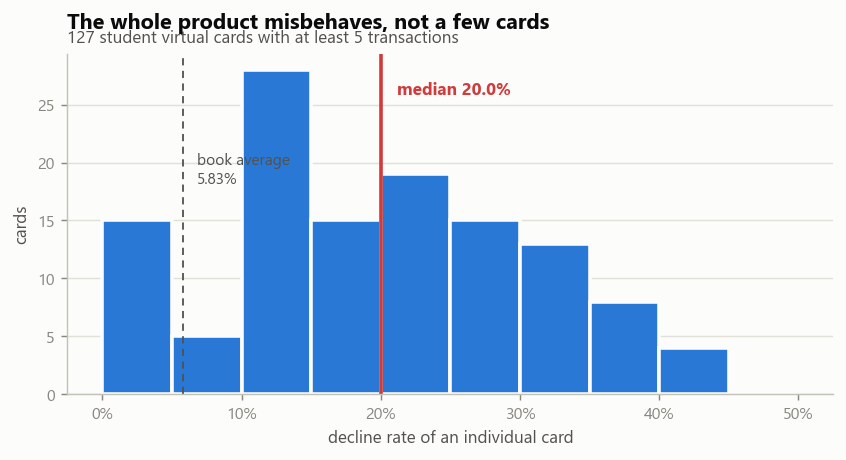

cards: 127   median 20.0%   never declined: 15   above 15%: 79


In [9]:
per_card = q("""
    SELECT c.card_id,
           count(*) AS txns,
           100.0 * count(*) FILTER (WHERE t.txn_status = 'declined') / count(*) AS decline_pct
    FROM uzcard.transactions t
    JOIN uzcard.cards c      ON c.card_id = t.card_id
    JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    WHERE cu.customer_segment = 'student' AND c.product_tier = 'virtual'
    GROUP BY c.card_id HAVING count(*) >= 5
""")

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.hist(per_card["decline_pct"], bins=np.arange(0, 55, 5),
        color=BLUE, edgecolor=SURFACE, linewidth=2)
median = per_card["decline_pct"].median()
ax.axvline(median, color=CRITICAL, lw=2)
ax.text(median + 1.2, ax.get_ylim()[1] * 0.88, f"median {median:.1f}%",
        color=CRITICAL, fontsize=9.5, fontweight="bold")
ax.axvline(5.83, color=INK_2, lw=1, ls=(0, (4, 3)))
ax.text(6.8, ax.get_ylim()[1] * 0.62, "book average\n5.83%", color=INK_2, fontsize=8.5)
ax.xaxis.set_major_formatter(PCT)
ax.set_xlabel("decline rate of an individual card")
ax.set_ylabel("cards")
ax.set_title("The whole product misbehaves, not a few cards")
finish(ax, f"{len(per_card)} student virtual cards with at least 5 transactions")
save(fig, "04-per-card-distribution")
plt.show()

print(f"cards: {len(per_card)}   median {median:.1f}%   "
      f"never declined: {(per_card.decline_pct == 0).sum()}   "
      f"above 15%: {(per_card.decline_pct >= 15).sum()}")

### 2.6 Stability across the year

saved assets/05-quarterly-stability.png


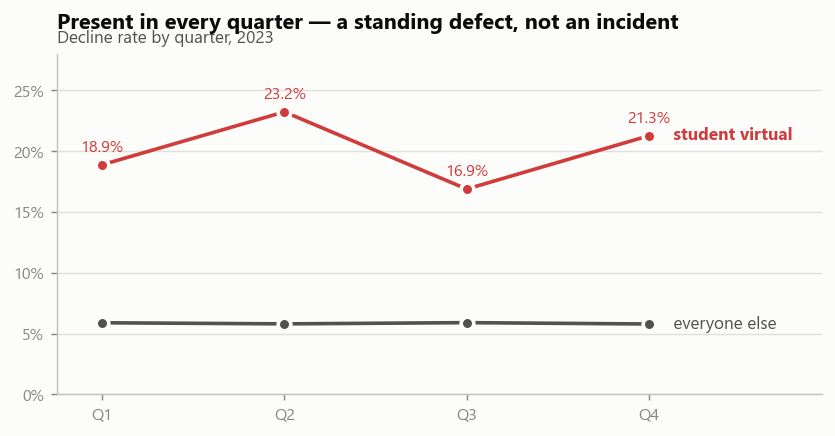

In [10]:
quarterly = q("""
    SELECT date_trunc('quarter', t.txn_ts)::date AS quarter,
           round(100.0 * count(*) FILTER (WHERE t.txn_status = 'declined'
                 AND cu.customer_segment = 'student' AND c.product_tier = 'virtual')
                 / nullif(count(*) FILTER (WHERE cu.customer_segment = 'student'
                 AND c.product_tier = 'virtual'), 0), 2) AS student_virtual,
           round(100.0 * count(*) FILTER (WHERE t.txn_status = 'declined'
                 AND NOT (cu.customer_segment = 'student' AND c.product_tier = 'virtual'))
                 / nullif(count(*) FILTER (WHERE NOT (cu.customer_segment = 'student'
                 AND c.product_tier = 'virtual')), 0), 2) AS everyone_else
    FROM uzcard.transactions t
    JOIN uzcard.cards c      ON c.card_id = t.card_id
    JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
    GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(7.6, 3.4))
labels = ["Q1", "Q2", "Q3", "Q4"]
ax.plot(labels, quarterly["student_virtual"], color=CRITICAL, lw=2,
        marker="o", markersize=7, markeredgecolor=SURFACE, markeredgewidth=2)
ax.plot(labels, quarterly["everyone_else"], color=INK_2, lw=2,
        marker="o", markersize=7, markeredgecolor=SURFACE, markeredgewidth=2)
ax.text(3.08, quarterly["student_virtual"].iloc[-1], "  student virtual",
        color=CRITICAL, fontsize=9.5, va="center", fontweight="bold")
ax.text(3.08, quarterly["everyone_else"].iloc[-1], "  everyone else",
        color=INK_2, fontsize=9.5, va="center")
for i, v in enumerate(quarterly["student_virtual"]):
    ax.text(i, v + 1.1, f"{v:.1f}%", ha="center", fontsize=9, color=CRITICAL)
ax.set_ylim(0, 28)
ax.set_xlim(-0.25, 3.95)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("Present in every quarter — a standing defect, not an incident")
finish(ax, "Decline rate by quarter, 2023")
save(fig, "05-quarterly-stability")
plt.show()

---

## 3. Disputes: two risk labels, one of which is inverted

Disputes are 0.33% of transactions, but the money has already moved — this is the
expensive failure. The denominator below is **approved** transactions only: a declined
payment never settles, so it can never be disputed.

### 3.1 Where they concentrate

saved assets/06-dispute-by-category.png


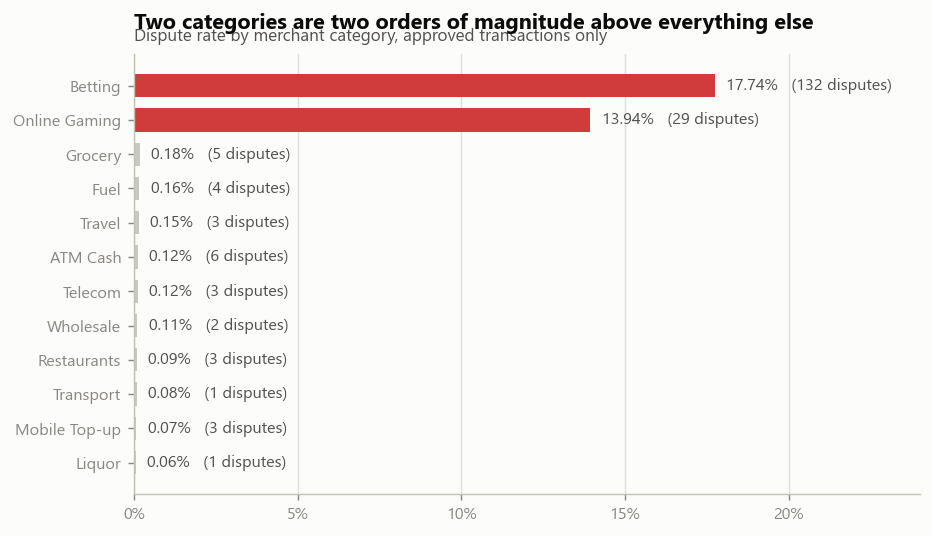

In [11]:
cat = q("""
    SELECT mc.category_name AS category,
           mc.is_high_risk,
           count(*) FILTER (WHERE t.txn_status = 'approved') AS approved,
           count(*) FILTER (WHERE t.is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 2)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
    JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
    GROUP BY 1, 2
    HAVING count(*) FILTER (WHERE t.txn_status = 'approved') > 0
    ORDER BY 5 DESC
""").head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(7.8, 4.4))
cols = [CRITICAL if v > 5 else NEUTRAL for v in cat["dispute_pct"]]
bars = ax.barh(cat["category"], cat["dispute_pct"], color=cols, height=0.68)
for bar, v, d in zip(bars, cat["dispute_pct"], cat["disputes"]):
    ax.text(v + 0.35, bar.get_y() + bar.get_height() / 2,
            f"{v:.2f}%   ({d} disputes)", va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, 24)
ax.xaxis.set_major_formatter(PCT)
ax.set_title("Two categories are two orders of magnitude above everything else")
finish(ax, "Dispute rate by merchant category, approved transactions only", xgrid=True)
save(fig, "06-dispute-by-category")
plt.show()

### 3.2 Does the bank's own merchant risk label add anything?

saved assets/07-inverted-risk-tier.png


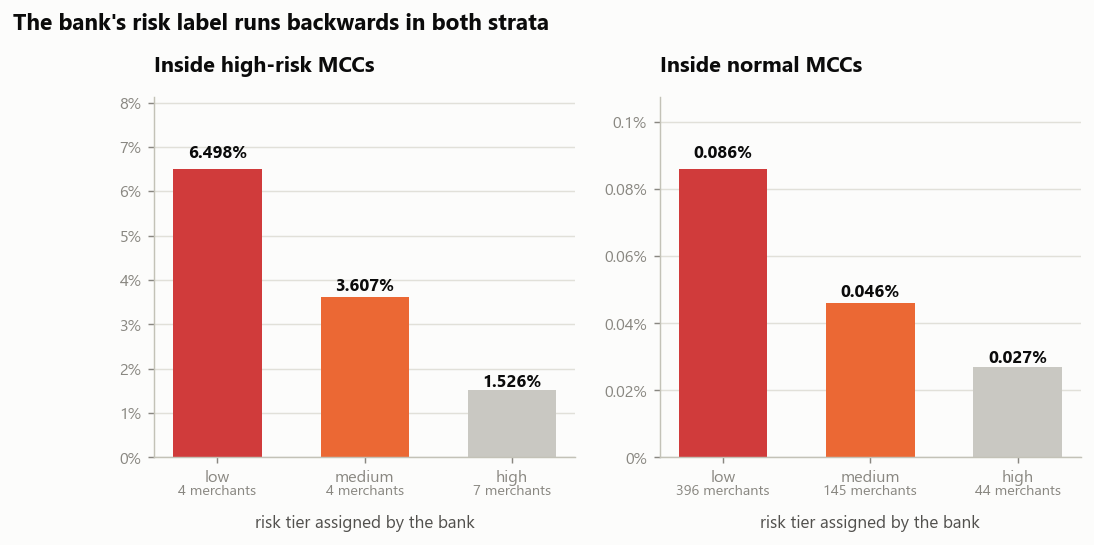

In [12]:
strata = q("""
    SELECT mc.is_high_risk AS mcc_high_risk,
           m.risk_tier,
           count(DISTINCT m.merchant_id) AS merchants,
           count(*) FILTER (WHERE t.txn_status = 'approved') AS approved,
           count(*) FILTER (WHERE t.is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 3)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
    JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
    GROUP BY 1, 2
""")

order = ["low", "medium", "high"]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6))
for ax, hr, title in zip(axes, [True, False],
                         ["Inside high-risk MCCs", "Inside normal MCCs"]):
    d = strata[strata.mcc_high_risk == hr].set_index("risk_tier").loc[order]
    bars = ax.bar(order, d["dispute_pct"], color=[CRITICAL, ORANGE, NEUTRAL], width=0.6)
    for bar, v, m in zip(bars, d["dispute_pct"], d["merchants"]):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.04,
                f"{v:.3f}%", ha="center", fontsize=9.5, color=INK, fontweight="bold")
        ax.text(bar.get_x() + bar.get_width() / 2, -max(d["dispute_pct"]) * 0.13,
                f"{m} merchants", ha="center", fontsize=8, color=MUTED)
    ax.set_ylim(0, max(d["dispute_pct"]) * 1.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}%"))
    ax.set_xlabel("risk tier assigned by the bank", labelpad=16)
    ax.set_title(title)
    finish(ax)
fig.suptitle("The bank's risk label runs backwards in both strata", x=0.007,
             ha="left", fontsize=12.5, fontweight="bold", color=INK, y=1.06)
save(fig, "07-inverted-risk-tier")
plt.show()

In both strata the dispute rate **falls** as the assigned risk rises. Inside high-risk MCCs
the low-vs-high gap is 4.97 points (z = 7.44, p < 0.001); inside normal MCCs the gap is
0.06 points and not significant (z = 1.19, p = 0.23).

The caveat belongs next to the finding: the high-risk stratum holds only 15 merchants
(4 low, 4 medium, 7 high). This is enough to say **the label is not working**, not enough
to quote as a precise effect size.

### 3.3 How concentrated is the exposure?

saved assets/08-dispute-concentration.png


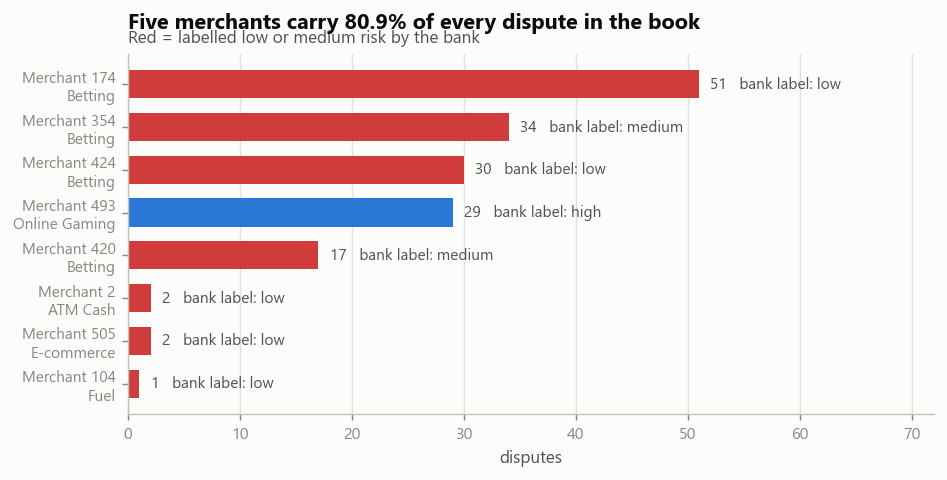

,merchant_name,category_name,bank_label,disputes,cumulative_pct
0,Merchant 174,Betting,low,51,25.6
1,Merchant 354,Betting,medium,34,42.7
2,Merchant 424,Betting,low,30,57.8
3,Merchant 493,Online Gaming,high,29,72.4
4,Merchant 420,Betting,medium,17,80.9
5,Merchant 2,ATM Cash,low,2,81.9
6,Merchant 505,E-commerce,low,2,82.9
7,Merchant 104,Fuel,low,1,83.4


In [13]:
conc = q("""
    WITH per_merchant AS (
        SELECT m.merchant_name, mc.category_name, m.risk_tier,
               count(*) FILTER (WHERE t.is_disputed) AS disputes
        FROM uzcard.transactions t
        JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
        JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
        GROUP BY 1, 2, 3
    )
    SELECT merchant_name, category_name, risk_tier AS bank_label, disputes,
           round(100.0 * sum(disputes) OVER (ORDER BY disputes DESC, merchant_name)
                 / sum(disputes) OVER (), 1) AS cumulative_pct
    FROM per_merchant WHERE disputes > 0
    ORDER BY disputes DESC LIMIT 8
""")

fig, ax = plt.subplots(figsize=(8.0, 3.6))
d = conc.iloc[::-1]
cols = [CRITICAL if lab in ("low", "medium") else BLUE for lab in d["bank_label"]]
bars = ax.barh(range(len(d)), d["disputes"], color=cols, height=0.66)
ax.set_yticks(range(len(d)),
              [f"{n}\n{c}" for n, c in zip(d["merchant_name"], d["category_name"])],
              fontsize=8.5)
for bar, v, lab in zip(bars, d["disputes"], d["bank_label"]):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            f"{v}   bank label: {lab}", va="center", fontsize=8.5, color=INK_2)
ax.set_xlim(0, 72)
ax.set_xlabel("disputes")
ax.set_title("Five merchants carry 80.9% of every dispute in the book")
finish(ax, "Red = labelled low or medium risk by the bank", xgrid=True)
save(fig, "08-dispute-concentration")
plt.show()

conc

The `is_high_risk` MCC flag covers four categories, but two of them are clean —
Crypto/FX (1 dispute on 2,857 approved) and Money Transfer (0 on 768) — and together they
are 79% of the flagged volume. Naming Betting and Online Gaming instead cuts the target
from **8.2% of volume to 1.7%** while still covering **80.9% of disputes**.

---

## 4. Channel shift: the growing channel is the risky one

saved assets/09-channel-share.png


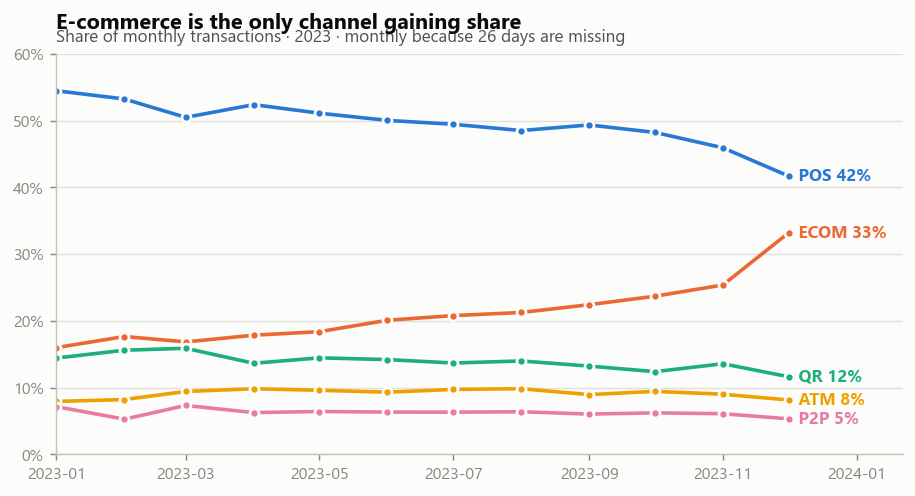

In [14]:
monthly = q("""
    WITH m AS (
        SELECT date_trunc('month', t.txn_ts)::date AS month, te.channel, count(*) AS txns
        FROM uzcard.transactions t
        JOIN uzcard.terminals te ON te.terminal_id = t.terminal_id
        GROUP BY 1, 2
    )
    SELECT month, channel,
           100.0 * txns / sum(txns) OVER (PARTITION BY month) AS share_pct
    FROM m ORDER BY month
""")
wide = monthly.pivot(index="month", columns="channel", values="share_pct")
wide = wide[["POS", "ECOM", "QR", "ATM", "P2P"]]

fig, ax = plt.subplots(figsize=(8.4, 4.0))
for i, ch in enumerate(wide.columns):
    ax.plot(wide.index, wide[ch], color=SERIES[i], lw=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=ch)
    # direct labels: three of these hues sit under 3:1 on the light surface, so the
    # label is the required relief - identity never rests on colour alone
    ax.text(wide.index[-1], wide[ch].iloc[-1], f"  {ch} {wide[ch].iloc[-1]:.0f}%",
            color=SERIES[i], fontsize=9.5, va="center", fontweight="bold")
ax.set_xlim(wide.index[0], wide.index[-1] + pd.Timedelta(days=52))
ax.set_ylim(0, 60)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("E-commerce is the only channel gaining share")
finish(ax, "Share of monthly transactions · 2023 · monthly because 26 days are missing")
save(fig, "09-channel-share")
plt.show()

In [15]:
shift = q("""
    WITH q AS (
        SELECT te.channel,
               count(*) FILTER (WHERE t.txn_ts <  '2023-04-01') AS q1,
               count(*) FILTER (WHERE t.txn_ts >= '2023-10-01') AS q4,
               count(*) FILTER (WHERE t.is_disputed) AS disputes
        FROM uzcard.transactions t
        JOIN uzcard.terminals te ON te.terminal_id = t.terminal_id
        GROUP BY 1
    )
    SELECT channel,
           round(100.0 * q1 / sum(q1) OVER (), 1) AS q1_share,
           round(100.0 * q4 / sum(q4) OVER (), 1) AS q4_share,
           round(100.0 * q4 / sum(q4) OVER () - 100.0 * q1 / sum(q1) OVER (), 1) AS shift_pts,
           round(100.0 * disputes / sum(disputes) OVER (), 1) AS pct_of_disputes
    FROM q ORDER BY shift_pts DESC
""")
shift

,channel,q1_share,q4_share,shift_pts,pct_of_disputes
0,ECOM,17.0,28.5,11.6,84.4
1,ATM,8.8,8.7,0.0,3.0
2,P2P,6.6,5.8,-0.8,0.5
3,QR,15.5,12.4,-3.2,3.0
4,POS,52.1,44.6,-7.5,9.0


E-commerce takes **+11.6 points** of share between Q1 and Q4, almost all of it from POS
(−7.5). It also produces **84.4%** of every dispute in the book. The channel the business
is moving into is the one it is least protected in — and the mix was still moving at the
end of the observation window.



---

## 5. From finding to decision: when, at what cost, and worth how much

Sections 2–4 end where most analyses end: a defect located, a label discredited, a channel
named. None of that is yet a decision. Three things are missing.

**When.** The hour of the transaction has not been cut anywhere above. A rule that fires
all day costs more than one that fires for five hours.

**What it costs.** Coverage is free to promise. Every flagged transaction is a step-up
prompt shown to a real customer, so a rule has to be scored on operating load, not only
on what it catches.

**How much it is worth.** Declines and disputes cannot be ranked against each other in
percentage points. They can be ranked in UZS.

### 5.1 The hour of the transaction

saved assets/12-dispute-hour-window.png


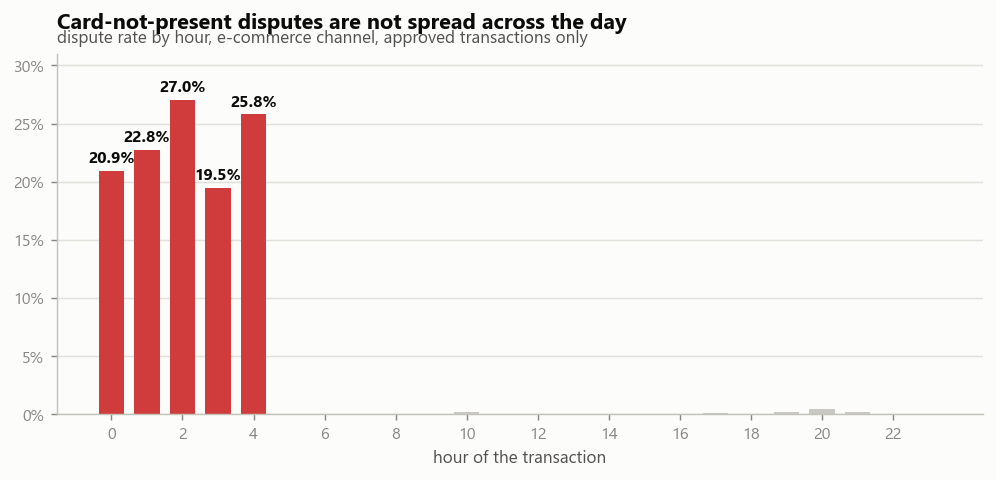

00:00-04:59   160 disputes on    687 approved
05:00-23:59     8 disputes on 12,815 approved


In [16]:
hourly = q("""
    SELECT extract(hour FROM t.txn_ts)::int AS hour_of_day,
           count(*) FILTER (WHERE t.txn_status = 'approved') AS approved,
           count(*) FILTER (WHERE t.is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 2)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.terminals te ON te.terminal_id = t.terminal_id
    WHERE te.channel = 'ECOM'
    GROUP BY 1
    ORDER BY 1
""")

NIGHT = range(0, 5)
fig, ax = plt.subplots(figsize=(9.2, 3.6))
colors = [CRITICAL if h in NIGHT else NEUTRAL for h in hourly.hour_of_day]
bars = ax.bar(hourly.hour_of_day, hourly.dispute_pct, color=colors, width=0.72)
for bar, h, v in zip(bars, hourly.hour_of_day, hourly.dispute_pct):
    if h in NIGHT:
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.7, f"{v:.1f}%",
                ha="center", fontsize=9, color=INK, fontweight="bold")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("hour of the transaction")
ax.set_ylim(0, 31)
ax.yaxis.set_major_formatter(PCT)
ax.set_title("Card-not-present disputes are not spread across the day")
finish(ax, "dispute rate by hour, e-commerce channel, approved transactions only")
save(fig, "12-dispute-hour-window")
plt.show()

print(f"00:00-04:59  {hourly.loc[hourly.hour_of_day < 5, 'disputes'].sum():>4} disputes "
      f"on {hourly.loc[hourly.hour_of_day < 5, 'approved'].sum():>6,} approved")
print(f"05:00-23:59  {hourly.loc[hourly.hour_of_day >= 5, 'disputes'].sum():>4} disputes "
      f"on {hourly.loc[hourly.hour_of_day >= 5, 'approved'].sum():>6,} approved")

Not a gradient — a cliff. The five hours from midnight run 19.5%–27.0%; the other nineteen
run at zero with five exceptions, none above 0.45%. **160 of the 168 card-not-present
disputes in the book happen between 00:00 and 04:59.**

A single cut is never enough to build a rule on, so the next cell asks the two questions
that could dissolve this one: does the clock do the same thing on every channel, and do
these merchants simply trade at night?

### 5.2 Neither condition works on its own

In [17]:
by_channel = q("""
    SELECT te.channel,
           CASE WHEN extract(hour FROM t.txn_ts) < 5 THEN '00:00-04:59'
                ELSE '05:00-23:59' END AS window,
           count(*) FILTER (WHERE t.txn_status = 'approved') AS approved,
           count(*) FILTER (WHERE t.is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 3)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.terminals te ON te.terminal_id = t.terminal_id
    GROUP BY 1, 2
    ORDER BY 1, 2
""")
print(by_channel.pivot(index="channel", columns="window", values="dispute_pct").to_string())

interaction = q("""
    SELECT CASE WHEN mc.category_name IN ('Betting', 'Online Gaming')
                THEN 'Betting / Online Gaming' ELSE 'every other category' END AS category_set,
           CASE WHEN extract(hour FROM t.txn_ts) < 5 THEN '00:00-04:59'
                ELSE '05:00-23:59' END AS window,
           count(*) FILTER (WHERE t.txn_status = 'approved') AS approved,
           count(*) FILTER (WHERE t.is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE t.is_disputed)
                 / nullif(count(*) FILTER (WHERE t.txn_status = 'approved'), 0), 3)
               AS dispute_pct
    FROM uzcard.transactions t
    JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
    JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
    GROUP BY 1, 2
""")
print(interaction.pivot(index="category_set", columns="window", values="dispute_pct").to_string())

cell_ = interaction.set_index(["category_set", "window"])
night = cell_.loc[("Betting / Online Gaming", "00:00-04:59")]
day = cell_.loc[("Betting / Online Gaming", "05:00-23:59")]
pd.DataFrame([two_prop(int(night.disputes), int(night.approved),
                       int(day.disputes), int(day.approved),
                       "target categories 00:00-04:59", "the same merchants 05:00-23:59")])

window   00:00-04:59  05:00-23:59
channel                          
ATM             0.00        0.122
ECOM           23.29        0.062
P2P             0.00        0.030
POS             0.00        0.069
QR              0.00        0.083


window                   00:00-04:59  05:00-23:59
category_set                                     
Betting / Online Gaming       46.921        0.164
every other category           0.000        0.071


,comparison,rate_a,rate_b,gap_pts,z,ci_95,p_value
0,target categories 00:00-04:59 vs the same merc...,46.92% (160/341),0.16% (1/611),46.76,18.45,"[41.45, 52.06]",4.95e-76


Both conditions are necessary and neither is sufficient:

| | 00:00–04:59 | 05:00–23:59 |
|---|---:|---:|
| **Betting / Online Gaming** | **46.921%** | 0.164% |
| every other category | 0.000% | 0.071% |

Card-present channels are flat across the clock — 0 disputes on 1,170 night transactions
across ATM, POS, P2P and QR. Every non-target category at night is also at zero. The rate
lives in the intersection, and the gap against the same merchants during the day is
**46.76 points** (z = 18.45, p < 0.001, 95% CI [41.45, 52.06]).

Nor is the window the category restated: these merchants trade around the clock — 341
approved transactions in the five night hours against 611 across the other nineteen. Night
is 36% of their volume and 99.4% of their disputes.

This is the same shape as the student virtual card in section 2: neither margin is
remarkable, the cell is. Two of the three findings in this notebook are interactions,
which is the argument for never stopping at a `GROUP BY`.

### 5.3 What is left of "e-commerce is risky"?

In [18]:
buckets = q("""
    WITH tagged AS (
        SELECT t.is_disputed,
               te.channel = 'ECOM' AS is_cnp,
               mc.category_name IN ('Betting', 'Online Gaming')
                   AND extract(hour FROM t.txn_ts) < 5 AS in_window
        FROM uzcard.transactions t
        JOIN uzcard.terminals te      ON te.terminal_id = t.terminal_id
        JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
        JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
        WHERE t.txn_status = 'approved'
    )
    SELECT CASE WHEN NOT is_cnp           THEN 'card-present (all channels)'
                WHEN is_cnp AND in_window THEN 'e-commerce, in the window'
                ELSE 'e-commerce, outside the window' END AS bucket,
           count(*) AS approved,
           count(*) FILTER (WHERE is_disputed) AS disputes,
           round(100.0 * count(*) FILTER (WHERE is_disputed) / count(*), 3) AS dispute_pct
    FROM tagged
    GROUP BY 1
    ORDER BY dispute_pct DESC
""")
buckets

,bucket,approved,disputes,dispute_pct
0,"e-commerce, in the window",341,160,46.921
1,card-present (all channels),42538,31,0.073
2,"e-commerce, outside the window",13161,8,0.061


Outside the window, card-not-present is **marginally safer than card-present** — 0.061%
against 0.073%. Section 4's "e-commerce carries 84.4% of disputes" is true of the channel
average and is the wrong basis for policy: blanket friction on e-commerce would tax 13,161
clean transactions to reach 8 disputes.

### 5.4 Scoring the rule: coverage against operating load

                          rule  flagged  step_ups_per_day  coverage_pct  precision_pct  uzs_protected_mln
           A  card-not-present    13502              40.2          84.4            1.2              103.2
     B  A + high-risk MCC flag      952               2.8          80.9           16.9              102.4
C  A + Betting / Online Gaming      952               2.8          80.9           16.9              102.4
            D  C + 00:00-04:59      341               1.0          80.4           46.9              102.3


saved assets/13-rule-tradeoff.png


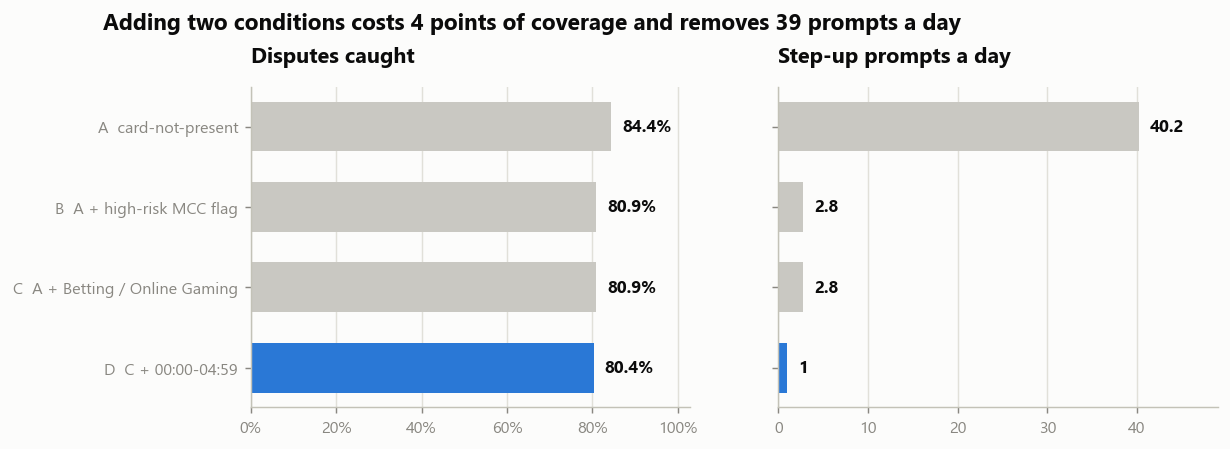

In [19]:
scored = q("""
    WITH base AS (
        SELECT t.amount_uzs, t.is_disputed,
               te.channel = 'ECOM' AS is_cnp,
               mc.is_high_risk AS mcc_flag,
               mc.category_name IN ('Betting', 'Online Gaming') AS target_cat,
               extract(hour FROM t.txn_ts) < 5 AS is_night
        FROM uzcard.transactions t
        JOIN uzcard.terminals te      ON te.terminal_id = t.terminal_id
        JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
        JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
        WHERE t.txn_status = 'approved'
    ),
    observed_days AS (
        SELECT count(DISTINCT date_trunc('day', txn_ts)) AS days FROM uzcard.transactions
    ),
    rules AS (
        SELECT * FROM (VALUES
            (1, 'A  card-not-present'),
            (2, 'B  A + high-risk MCC flag'),
            (3, 'C  A + Betting / Online Gaming'),
            (4, 'D  C + 00:00-04:59')
        ) AS r(id, rule)
    ),
    fired AS (
        SELECT r.id, r.rule, b.is_disputed, b.amount_uzs,
               CASE r.id
                   WHEN 1 THEN b.is_cnp
                   WHEN 2 THEN b.is_cnp AND b.mcc_flag
                   WHEN 3 THEN b.is_cnp AND b.target_cat
                   WHEN 4 THEN b.is_cnp AND b.target_cat AND b.is_night
               END AS fires
        FROM base b CROSS JOIN rules r
    )
    SELECT f.rule,
           count(*) FILTER (WHERE f.fires) AS flagged,
           round(count(*) FILTER (WHERE f.fires)::numeric / d.days, 1) AS step_ups_per_day,
           round(100.0 * count(*) FILTER (WHERE f.fires AND f.is_disputed)
                 / count(*) FILTER (WHERE f.is_disputed), 1) AS coverage_pct,
           round(100.0 * count(*) FILTER (WHERE f.fires AND f.is_disputed)
                 / nullif(count(*) FILTER (WHERE f.fires), 0), 1) AS precision_pct,
           round(sum(f.amount_uzs) FILTER (WHERE f.fires AND f.is_disputed) / 1e6, 1)
               AS uzs_protected_mln
    FROM fired f CROSS JOIN observed_days d
    GROUP BY f.id, f.rule, d.days
    ORDER BY f.id
""")
print(scored.to_string(index=False))

order = scored.iloc[::-1]          # rule A at the top of a horizontal chart
y = np.arange(len(order))
picked = [BLUE if r.startswith("D") else NEUTRAL for r in order.rule]

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2), sharey=True)
for ax, col, title, fmt in [
    (axes[0], "coverage_pct", "Disputes caught", lambda v: f"{v:.1f}%"),
    (axes[1], "step_ups_per_day", "Step-up prompts a day", lambda v: f"{v:g}"),
]:
    bars = ax.barh(y, order[col], color=picked, height=0.62)
    for bar, v in zip(bars, order[col]):
        ax.text(v + order[col].max() * 0.03, bar.get_y() + bar.get_height() / 2,
                fmt(v), va="center", fontsize=9.5, color=INK, fontweight="bold")
    ax.set_xlim(0, order[col].max() * 1.22)
    ax.set_title(title)
    finish(ax, xgrid=True)
axes[0].set_yticks(y, order.rule)
axes[0].xaxis.set_major_formatter(PCT)
fig.suptitle("Adding two conditions costs 4 points of coverage and removes 39 prompts a day",
             x=0.007, ha="left", fontsize=12.5, fontweight="bold", color=INK, y=1.06)
save(fig, "13-rule-tradeoff")
plt.show()

Read the first and last rows together. Rule D gives up **4 points of coverage and 0.9 mln
UZS** against the blanket card-not-present rule, and costs **1 prompt a day instead of 40**.
Nearly half of D's prompts land on a transaction that really is disputed — 46.9% precision
against 1.2%.

Two results worth stating rather than hiding:

- **B and C are identical.** Once card-not-present is required, the MCC flag and the two
  named categories select the same 952 transactions, because Crypto/FX and Money Transfer
  settle on P2P and QR and never on ECOM. The flag is over-broad only when used alone.
- **A fifth rule was tested and rejected.** "The five named merchants, 00:00–04:59" selects
  *exactly* the same 341 transactions as D. Naming merchants buys nothing over naming the
  categories, and it would need re-cutting every time a merchant is onboarded.

### 5.5 What each finding is worth

In [20]:
money = q("""
    WITH disputes AS (
        SELECT sum(t.amount_uzs) AS uzs
        FROM uzcard.transactions t
        JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
        JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
        WHERE t.is_disputed AND mc.category_name IN ('Betting', 'Online Gaming')
    ),
    cells AS (
        SELECT cu.customer_segment = 'student' AND c.product_tier = 'virtual' AS is_cell,
               count(*) AS txns,
               count(*) FILTER (WHERE t.txn_status = 'declined') AS declined,
               avg(t.amount_uzs) FILTER (WHERE t.txn_status = 'declined') AS avg_ticket
        FROM uzcard.transactions t
        JOIN uzcard.cards c      ON c.card_id = t.card_id
        JOIN uzcard.customers cu ON cu.customer_id = c.customer_id
        GROUP BY 1
    ),
    declines AS (
        SELECT cell.txns * (cell.declined::numeric / cell.txns
                            - rest.declined::numeric / rest.txns) * cell.avg_ticket AS uzs,
               cell.txns * (cell.declined::numeric / cell.txns
                            - rest.declined::numeric / rest.txns) AS excess
        FROM (SELECT * FROM cells WHERE is_cell) cell
        CROSS JOIN (SELECT * FROM cells WHERE NOT is_cell) rest
    )
    SELECT 'Disputes: Betting and Online Gaming, card-not-present' AS finding,
           round(uzs / 1e6, 1) AS mln_uzs,
           'step-up on rule D, 1 prompt a day' AS fix
    FROM disputes
    UNION ALL
    SELECT 'Declines: the student virtual card',
           round(uzs / 1e6, 1),
           'product audit on 134 cards, 107 customers'
    FROM declines
    ORDER BY mln_uzs DESC
""")
print(money.to_string(index=False))
print(f"\nthe dispute finding is worth {money.mln_uzs.iloc[0] / money.mln_uzs.iloc[1]:.1f}x the decline finding")


                                              finding  mln_uzs                                       fix
Disputes: Betting and Online Gaming, card-not-present    102.4         step-up on rule D, 1 prompt a day
                   Declines: the student virtual card     16.2 product audit on 134 cards, 107 customers

the dispute finding is worth 6.3x the decline finding


| finding | exposure | fix |
|---|---:|---|
| Disputes: Betting and Online Gaming, card-not-present | **102.4 mln UZS** | step-up on rule D, 1 prompt a day |
| Declines: the student virtual card | **16.2 mln UZS** | product audit on 134 cards, 107 customers |

**The assumption, stated because it changes the size of the number.** Both figures are
*exposure*, not booked loss. A dispute may be resolved in the bank's favour; a declined
customer may succeed on a retry. This data has no dispute outcome and no retry linkage, so
these are upper bounds — the right numbers for ranking two fixes against each other, the
wrong numbers for a P&L line.

The dispute finding is worth **6.3×** the decline finding and is the cheaper of the two to
act on. That decides the order of the recommendations, and it is the reverse of the order
the findings arrive in when the analysis is read front to back.

### 5.6 Does the rule need more capacity as e-commerce grows?

In [21]:
capacity = q("""
    WITH base AS (
        SELECT date_trunc('quarter', t.txn_ts)::date AS quarter,
               t.amount_uzs, t.is_disputed,
               te.channel = 'ECOM' AS is_cnp,
               mc.category_name IN ('Betting', 'Online Gaming')
                   AND extract(hour FROM t.txn_ts) < 5 AS in_window
        FROM uzcard.transactions t
        JOIN uzcard.terminals te      ON te.terminal_id = t.terminal_id
        JOIN uzcard.merchants m       ON m.merchant_id = t.merchant_id
        JOIN uzcard.mcc_categories mc ON mc.mcc_code = m.mcc_code
        WHERE t.txn_status = 'approved'
    ),
    days AS (
        SELECT date_trunc('quarter', txn_ts)::date AS quarter,
               count(DISTINCT date_trunc('day', txn_ts)) AS days
        FROM uzcard.transactions GROUP BY 1
    )
    SELECT b.quarter,
           count(*) AS approved,
           round(100.0 * count(*) FILTER (WHERE b.is_cnp) / count(*), 1) AS ecom_share_pct,
           round(count(*) FILTER (WHERE b.is_cnp AND b.in_window)::numeric / d.days, 1)
               AS step_ups_per_day,
           round(sum(b.amount_uzs) FILTER (WHERE b.is_disputed) / 1e6, 1) AS disputed_mln
    FROM base b JOIN days d ON d.quarter = b.quarter
    GROUP BY b.quarter, d.days
    ORDER BY b.quarter
""")
capacity

,quarter,approved,ecom_share_pct,step_ups_per_day,disputed_mln
0,2023-01-01,4013,17.3,1.0,24.7
1,2023-04-01,9915,19.0,1.0,26.6
2,2023-07-01,16031,21.7,1.1,30.5
3,2023-10-01,26081,28.5,1.0,31.9


The answer is no. Approved volume grows **6.5×** across the year and the card-not-present
share gains 11.2 points, while the rule's load stays at **one transaction a day** — the
exposure is anchored to five merchants whose own volume is flat. Dispute value rises 29%
while the book grows 550%.

So "invest in card-not-present capacity" is the wrong ask. The rule ships at current
headcount, and the thing to monitor is not e-commerce volume — it is whether a sixth
merchant ever joins the five.

---

## 6. What this adds up to

**On disputes — 102.4 mln UZS of exposure, the largest of the two findings.** The bank has
a label that works (MCC `is_high_risk`, 49× separation) and a label that is inverted where
it matters (`risk_tier`). Five merchants out of 600 carry 80.9% of the exposure and three
of them are labelled low or medium risk. Adding the hour of the transaction narrows the
target to 0.61% of approved volume at 46.9% precision: one step-up prompt a day protects
102.3 mln UZS. This is an enforcement list with a time window, not a policy.

**On declines — 16.2 mln UZS, and a different fix than the obvious one.** The segment-level
view says "students are a credit risk" and points at 209 customers. The product-level view
says one card product is defective and points at 134 cards. Acting on the first would
tighten limits for 102 students whose cards work exactly as well as everyone else's, and
would leave the actual defect running.

**On growth — not a spend decision.** E-commerce gains 11.6 points of share and carries
84.4% of disputes, but its risk is not the channel: outside one five-hour window at two
merchant categories, card-not-present is safer than card-present. The rule's operating load
was flat at 1/day through a year in which the book grew 6.5×, so the queue does not have to
scale with the channel.

### Limitations

- Synthetic course data — internally consistent (35 of 35 relationships have zero orphan
  rows) but generated, so this demonstrates method rather than describing a real market.
  The 00:00–04:59 window is unusually clean for behavioural data; in a real book expect a
  gradient rather than a cliff, and re-fit the window rather than reusing these five hours.
- Both money figures are **exposure, not loss**: `is_disputed` is a flag with no resolution
  or chargeback outcome, and declines have no retry linkage, so a customer who succeeds on
  a second attempt is still counted. They rank the two fixes; they do not size a P&L line.
- The inverted `risk_tier` rests on 15 merchants in the stratum that matters.
- Rule D is scored on the same year it was fitted on. The honest next step is a holdout
  period, which one year of data cannot provide.
- Observational. The student virtual card finding survives controls for credit limit,
  channel, quarter and the per-card distribution, but it locates a defect; it does not
  explain the mechanism.

In [22]:
con.close()